In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../pakistan_economic_indicators_2000_2025.csv")

sns.set_theme(style="whitegrid")

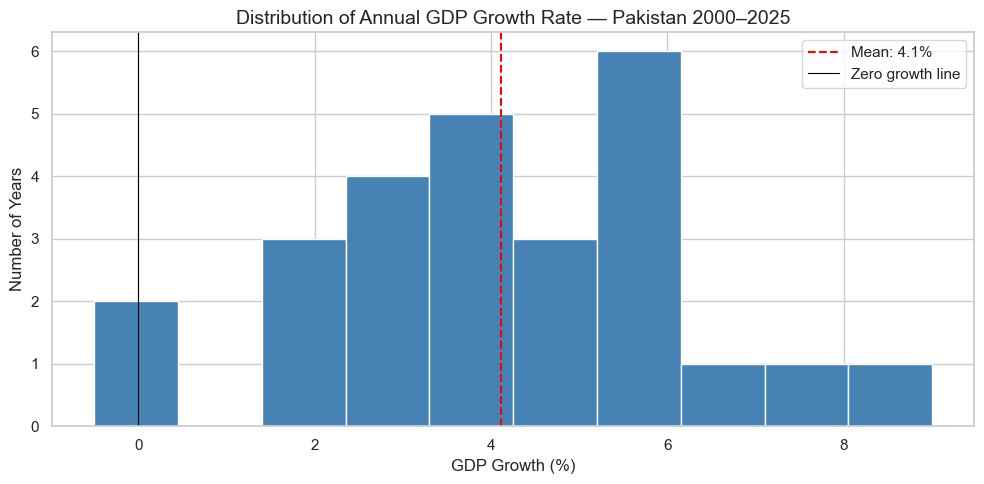

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(df["gdp_growth_pct"], bins=10, color="steelblue", edgecolor="white")

plt.title("Distribution of Annual GDP Growth Rate — Pakistan 2000–2025", fontsize=14)
plt.xlabel("GDP Growth (%)")
plt.ylabel("Number of Years")

plt.axvline(df["gdp_growth_pct"].mean(), color="red", linestyle="--", label=f"Mean: {df['gdp_growth_pct'].mean():.1f}%")
plt.axvline(0, color="black", linestyle="-", linewidth=0.8, label="Zero growth line")


plt.legend()
plt.tight_layout()
plt.show()

Most years cluster between 2–6% growth which looks healthy on the surface. But in the left tail, years near or below zero which represents the crisis episodes. The mean sits around 4% but that number flatters the picture because it gets dragged up by the 8–9% boom years of 2004–2005. A country with this distribution is not a stable grower as it swings between booms and near-recessions.

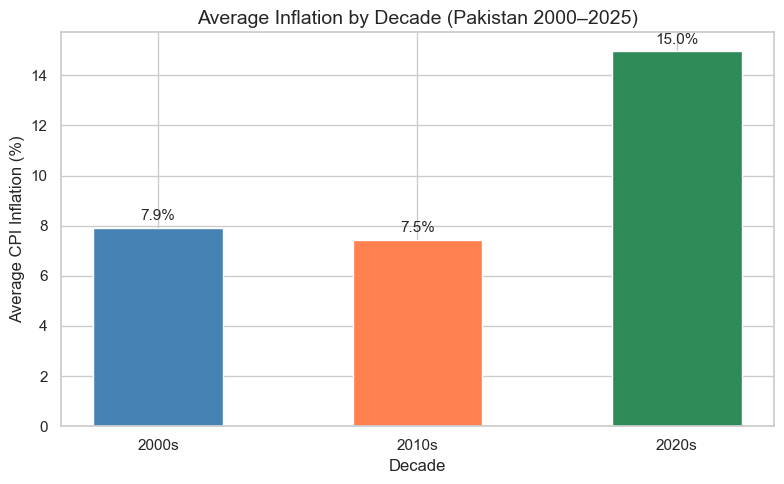

In [15]:
decade_inflation = df.groupby("decade", observed=True)["inflation_cpi_pct"].mean().reset_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    decade_inflation["decade"],
    decade_inflation["inflation_cpi_pct"],
    color=["steelblue", "coral", "seagreen"],
    edgecolor="white",
    width=0.5
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center", fontsize=11
    )

plt.title("Average Inflation by Decade (Pakistan 2000–2025)", fontsize=14)
plt.xlabel("Decade")
plt.ylabel("Average CPI Inflation (%)")
plt.tight_layout()
plt.show()

Inflation nearly doubled from the 2000s to the 2020s. The 2000s average looks low because Pakistan had a long stable stretch from 2000–2007 before the crisis hit. The 2020s average is being dragged up by 2023's 29.2% which was the worst in 25 years. The trend is going the wrong direction and the 2020s decade isn't even finished yet.

C:\Users\Rania Shoaib\AppData\Local\Temp\ipykernel_12920\30429865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


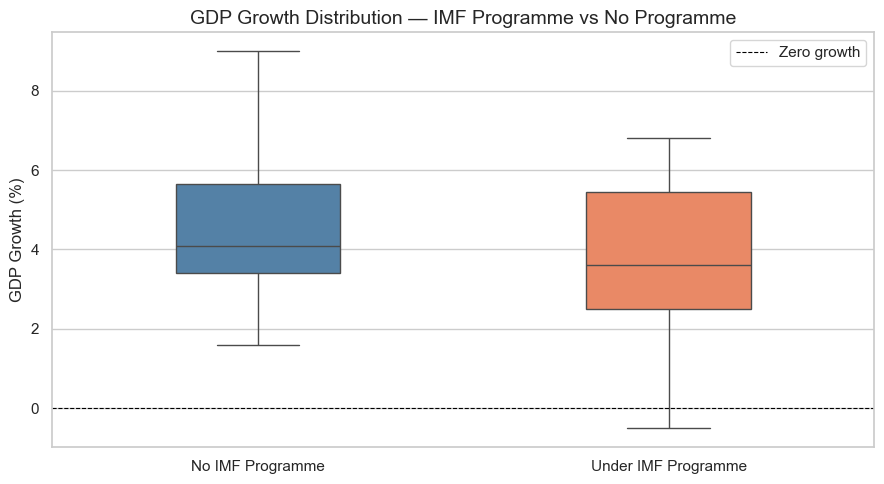

In [16]:
df["IMF Status"] = df["imf_program_active"].map({0: "No IMF Programme", 1: "Under IMF Programme"})

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="IMF Status",
    y="gdp_growth_pct",
    palette={"No IMF Programme": "steelblue", "Under IMF Programme": "coral"},
    width=0.4
)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8, label="Zero growth")

plt.title("GDP Growth Distribution — IMF Programme vs No Programme", fontsize=14)
plt.xlabel("")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.tight_layout()
plt.show()

 The box shows where the middle 50% of years sit. The line inside the box is the median. IMF programme years have a lower median and a longer bottom whisker which means not just lower average growth but more years where growth nearly collapsed. 

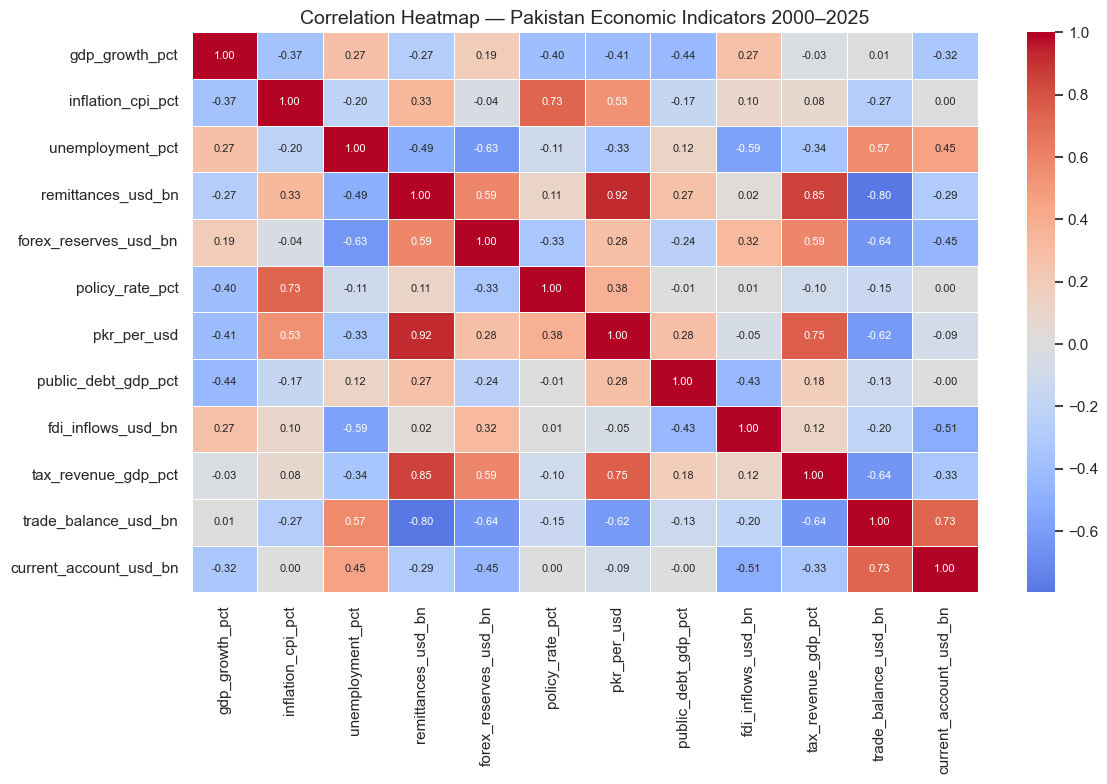

In [17]:
numeric_cols = [
    "gdp_growth_pct", "inflation_cpi_pct", "unemployment_pct",
    "remittances_usd_bn", "forex_reserves_usd_bn", "policy_rate_pct",
    "pkr_per_usd", "public_debt_gdp_pct", "fdi_inflows_usd_bn",
    "tax_revenue_gdp_pct", "trade_balance_usd_bn", "current_account_usd_bn"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap — Pakistan Economic Indicators 2000–2025", fontsize=14)
plt.tight_layout()
plt.show()

Red means two things move together, blue means they move in opposite directions, white means no relationship. A few relationships jump out immediately. PKR and remittances are strongly positive becasue as the rupee weakened, diaspora sent more dollars home, possibly because their money went further. GDP growth and inflation show almost no correlation, confirming that Pakistan's inflation is cost-push from imports and currency, not demand-pull from a hot economy. Trade balance and current account are almost perfectly correlated because the trade deficit dominates the current account. Any cell close to 1.0 or -1.0 is worth investigating which it means those two indicators are almost redundant, they're measuring the same underlying pressure.